# Adversarial Stochastic Discount Factors

**Docker image**: `ml4t-gpu`

**Chapter 14: Latent Factor Models**

Chen, Pelger, and Zhu learn a stochastic discount factor (SDF) by making a
portfolio-weight network compete with an adversarial moment network. This
notebook implements a daily educational adaptation of that design:

$$M_{t+1}=1-\omega_t^{\top}R^e_{t+1}, \qquad
F_{t+1}=\omega_t^{\top}R^e_{t+1}.$$

Information through close $t$ determines weights and instruments; the next
trading day's excess return realizes the factor. A separate beta network
estimates $E_t[R^e_{i,t+1}F_{t+1}]$, the paper's asset-level predictive head.
This SDF is the chapter's exception: it does not expose a swappable Stage 2
factor-premium forecaster.

**Learning objectives**

- align characteristics and macro state at $t$ with excess returns at $t+1$;
- implement the unconditional, adversarial, and conditional training phases;
- separate validation-selected SDF training from a once-only test evaluation;
- distinguish factor Sharpe and pricing errors from asset-level rank IC; and
- interpret beta-network predictions without confusing them with SDF weights.

**Evaluation contract**: the universe, return clipping, macro normalization,
and model checkpoints use training or validation data only. One return date is
embargoed at each boundary for the one-trading-day label. Test metrics are
computed only after the SDF and beta checkpoints are frozen.

**Data limitation**: this is not a reproduction of the paper's monthly CRSP
panel. It uses a training-defined 200-stock daily universe and a small set of
market-observed FRED series. FRED values come from the current snapshot, not a
vintage database; every series is delayed by one calendar day, and revised
lower-frequency releases are excluded.

**Attribution**: Chen, Pelger, and Zhu (2024), "Deep Learning in Asset
Pricing," *Management Science* 70(2), 714-750. See the
[paper](https://pubsonline.informs.com/doi/10.1287/mnsc.2023.4695) and the
[authors' empirical page](https://web.stanford.edu/~lych/demo-dlap.html).

**Prerequisite**: [`06_conditional_autoencoder`](06_conditional_autoencoder.ipynb)

**Book reference**: Section 14.7 (The stochastic discount factor and the
supervised autoencoder models)

## 1. Setup

In [1]:
"""Estimate an adversarial SDF and its asset-level beta-network signal."""

from copy import deepcopy
from time import perf_counter
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from ml4t.diagnostic.metrics.uncertainty import compute_ic_uncertainty

from data import load_macro, load_us_equities
from utils.reproducibility import set_global_seeds
from utils.style import (
    COLORS,
    FIGSIZE,
    add_message_title,
    ml4t_palette,
    show_with_alt,
    zero_line,
)

In [2]:
N_STOCKS = 200
START_DATE = "2000-01-01"
END_DATE = "2018-03-27"
UNCONDITIONAL_EPOCHS = 512
INSTRUMENT_EPOCHS = 64
CONDITIONAL_EPOCHS = 2_048
ADVERSARIAL_ROUNDS = 3
BETA_EPOCHS = 512
EVAL_EVERY = 16
CONDITIONAL_PATIENCE = 20
BETA_PATIENCE = 30
RETURN_CLIP_QUANTILES = (0.001, 0.999)
N_INSTRUMENTS = 8
N_BOOTSTRAP = 2_000
LEARNING_RATE = 0.001
LOSS_SCALE = 10_000.0
SEED = 42

In [3]:
set_global_seeds(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(
    f"Device={device}, stocks={N_STOCKS}, rounds={ADVERSARIAL_ROUNDS}, "
    f"conditional epochs={CONDITIONAL_EPOCHS}"
)

Device=cuda, stocks=200, rounds=3, conditional epochs=2048


## 2. Point-in-time panel

Split dates are fixed from the equity calendar before any universe or model
decision. The boundary return date is omitted at each split, providing a
one-period embargo for the next-day label.

In [4]:
equities_raw = load_us_equities(start_date=START_DATE, end_date=END_DATE)
macro_raw = load_macro()
calendar = equities_raw["timestamp"].unique().sort().to_list()
train_boundary = calendar[int(0.60 * len(calendar))]
test_boundary = calendar[int(0.80 * len(calendar))]
print(
    f"Raw equities={equities_raw.shape}, macro={macro_raw.shape}, "
    f"boundaries={train_boundary}/{test_boundary}"
)

Raw equities=(11343920, 14), macro=(9497, 26), boundaries=2010-11-22/2014-07-03


The universe uses average dollar volume observed strictly before the first
boundary. This avoids using future trading activity to decide which stocks
appear in the historical training panel.

In [5]:
liquidity = (
    equities_raw.filter(pl.col("timestamp") < train_boundary)
    .group_by("symbol")
    .agg(
        (pl.col("close") * pl.col("volume")).mean().alias("dollar_volume"),
        pl.len().alias("n_days"),
    )
    .filter(pl.col("n_days") >= 252)
    .sort(["dollar_volume", "symbol"], descending=[True, False])
)
symbols = liquidity.head(N_STOCKS)["symbol"].to_list()
equities = equities_raw.filter(pl.col("symbol").is_in(symbols)).sort(["symbol", "timestamp"])
print(f"Training-defined universe: {len(symbols)} stocks")

Training-defined universe: 200 stocks


Eight trailing characteristics use information available at the decision
close. Each is ranked within that date and mapped to $[-0.5,0.5]$, matching
the paper's robust cross-sectional normalization idea without fitting a
full-sample scaler.

In [6]:
feature_names = [
    "mom_5d",
    "mom_20d",
    "mom_60d",
    "vol_20d",
    "vol_60d",
    "zscore_20d",
    "volume_ratio",
    "log_dollar_volume",
]
feature_panel = equities.with_columns(
    pl.col("adj_close").pct_change().over("symbol").alias("return"),
    (pl.col("close") * pl.col("volume")).alias("dollar_volume"),
).with_columns(
    pl.col("adj_close").pct_change(5).over("symbol").alias("mom_5d"),
    pl.col("adj_close").pct_change(20).over("symbol").alias("mom_20d"),
    pl.col("adj_close").pct_change(60).over("symbol").alias("mom_60d"),
    pl.col("return").rolling_std(20).over("symbol").alias("vol_20d"),
    pl.col("return").rolling_std(60).over("symbol").alias("vol_60d"),
    (
        (pl.col("adj_close") - pl.col("adj_close").rolling_mean(20).over("symbol"))
        / pl.col("adj_close").rolling_std(20).over("symbol")
    ).alias("zscore_20d"),
    (pl.col("volume") / pl.col("volume").rolling_mean(20).over("symbol")).alias("volume_ratio"),
    pl.when(pl.col("dollar_volume") > 0)
    .then(pl.col("dollar_volume").log())
    .otherwise(None)
    .alias("log_dollar_volume"),
)

In [7]:
feature_panel = feature_panel.drop_nulls(subset=["return", *feature_names]).with_columns(
    [
        (pl.col(name).rank("average").over("timestamp") / pl.len().over("timestamp") - 0.5).alias(
            name
        )
        for name in feature_names
    ]
)

A global trading-date map pairs decision date $t$ with return date $t+1$.
Joining again on `symbol` drops a stock-specific gap instead of carrying a
stale characteristic into a later return.

In [8]:
decision_dates = feature_panel["timestamp"].unique().sort().to_list()
date_map = pl.DataFrame(
    {"decision_timestamp": decision_dates[:-1], "timestamp": decision_dates[1:]}
)
panel = (
    feature_panel.select(pl.col("timestamp").alias("decision_timestamp"), "symbol", *feature_names)
    .join(date_map, on="decision_timestamp", how="inner")
    .join(
        feature_panel.select("timestamp", "symbol", "return"),
        on=["timestamp", "symbol"],
        how="inner",
    )
)

The macro state uses only daily market series. Forward fill operates in
source-time order, then every observation receives a one-calendar-day
availability delay. No backward fill is used. The lagged federal funds rate
supplies a simple daily risk-free proxy for excess returns.

In [9]:
macro_names = ["dff", "dgs1", "dgs2", "dgs5", "dgs10", "dgs30", "t10y2y", "vixcls"]
macro_source = (
    macro_raw.select("timestamp", *macro_names)
    .sort("timestamp")
    .with_columns([pl.col(name).fill_nan(None).forward_fill() for name in macro_names])
    .with_columns((pl.col("timestamp") + pl.duration(days=1)).alias("available_timestamp"))
    .drop("timestamp")
)
macro_dates = pl.DataFrame({"decision_timestamp": panel["decision_timestamp"].unique().sort()})
macro_panel = macro_dates.join_asof(
    macro_source,
    left_on="decision_timestamp",
    right_on="available_timestamp",
    strategy="backward",
).drop_nulls(subset=macro_names)

Macro means and scales, and the return clipping thresholds, are learned from
training rows only. Date-local coverage filtering removes thin early
cross-sections without consulting later outcomes.

In [10]:
macro_train = macro_panel.filter(pl.col("decision_timestamp") < train_boundary)
macro_means = {name: float(macro_train[name].mean()) for name in macro_names}
macro_stds = {name: max(float(macro_train[name].std()), 1e-8) for name in macro_names}
macro_panel = macro_panel.with_columns(
    (pl.col("dff") / (100.0 * 252.0)).alias("risk_free"),
    *[((pl.col(name) - macro_means[name]) / macro_stds[name]).alias(name) for name in macro_names],
)
panel = panel.join(macro_panel, on="decision_timestamp", how="inner").with_columns(
    (pl.col("return") - pl.col("risk_free")).alias("excess_return")
)
min_assets = int(0.60 * len(symbols))
eligible_dates = (
    panel.group_by("timestamp").len().filter(pl.col("len") >= min_assets).select("timestamp")
)
panel = panel.join(eligible_dates, on="timestamp", how="semi")

In [11]:
train_returns = panel.filter(pl.col("timestamp") < train_boundary)["excess_return"]
clip_low = float(train_returns.quantile(RETURN_CLIP_QUANTILES[0]))
clip_high = float(train_returns.quantile(RETURN_CLIP_QUANTILES[1]))
panel = panel.with_columns(pl.col("excess_return").clip(clip_low, clip_high))
print(f"Training excess-return clip: [{clip_low:.4f}, {clip_high:.4f}]")

Training excess-return clip: [-0.1687, 0.1894]


Dense tensors retain a Boolean observation mask. Missing asset-days are zero
only after the mask is constructed, so zeros cannot be mistaken for observed
returns in losses or metrics.

In [12]:
class DataSplit(NamedTuple):
    """One chronological panel segment."""

    returns: torch.Tensor
    features: torch.Tensor
    macro: torch.Tensor
    mask: torch.Tensor
    dates: list

The pivot helper preserves the training-defined symbol order for every split.

In [13]:
def pivot_value(frame: pl.DataFrame, value: str, dates: list) -> np.ndarray:
    """Pivot one long panel column to the fixed date-by-symbol grid."""
    wide = frame.select("timestamp", "symbol", value).pivot(
        on="symbol", index="timestamp", values=value
    )
    wide = pl.DataFrame({"timestamp": dates}).join(wide, on="timestamp", how="left")
    missing = [symbol for symbol in symbols if symbol not in wide.columns]
    if missing:
        wide = wide.with_columns([pl.lit(None).cast(pl.Float64).alias(s) for s in missing])
    return wide.select(symbols).to_numpy().astype(np.float32)

Boundary dates are excluded. Validation and test therefore begin after a
one-return-date embargo, equal to the one-period label horizon.

In [14]:
split_frames = {
    "train": panel.filter(pl.col("timestamp") < train_boundary),
    "valid": panel.filter(
        (pl.col("timestamp") > train_boundary) & (pl.col("timestamp") < test_boundary)
    ),
    "test": panel.filter(pl.col("timestamp") > test_boundary),
}


def make_split(name: str, frame: pl.DataFrame) -> DataSplit:
    """Convert one long split to masked tensors."""
    dates = frame["timestamp"].unique().sort().to_list()
    returns = pivot_value(frame, "excess_return", dates)
    mask = np.isfinite(returns)
    feature_arrays = [pivot_value(frame, feature, dates) for feature in feature_names]
    features = np.stack(feature_arrays, axis=-1)
    macro = (
        frame.group_by("timestamp")
        .agg([pl.col(column).first() for column in macro_names])
        .sort("timestamp")
        .select(macro_names)
        .to_numpy()
        .astype(np.float32)
    )
    return DataSplit(
        torch.tensor(np.where(mask, returns, 0.0), device=device),
        torch.tensor(np.where(np.isfinite(features), features, 0.0), device=device),
        torch.tensor(macro, device=device),
        torch.tensor(mask, dtype=torch.bool, device=device),
        dates,
    )

In [15]:
data = {name: make_split(name, frame) for name, frame in split_frames.items()}
for name, split in data.items():
    print(
        f"{name}: observations={int(split.mask.sum()):,}, dates={len(split.dates)}, "
        f"symbols={int(split.mask.any(dim=0).sum())}"
    )

train: observations=503,311, dates=2678, symbols=200
valid: observations=181,167, dates=907, symbols=200
test: observations=174,575, dates=938, symbols=199


## 3. Adversarial networks

The SDF network combines an LSTM macro state with each asset's ranked
characteristics. A bounded output and per-date gross normalization prevent a
few observations from creating an unstable factor while retaining both long
and short weights.

In [16]:
class SDFNetwork(nn.Module):
    """Map current information to normalized SDF portfolio weights."""

    def __init__(self, n_features: int, n_macro: int, state_dim: int = 8):
        super().__init__()
        self.state_dim = state_dim
        self.lstm = nn.LSTM(n_macro, state_dim, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(n_features + state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Tanh(),
        )

    def forward(self, features, macro, mask, state=None):
        macro_state, state = self.lstm(macro.unsqueeze(0), state)
        expanded = macro_state.squeeze(0).unsqueeze(1).expand(-1, features.shape[1], -1)
        raw = self.ffn(torch.cat([features, expanded], dim=-1)).squeeze(-1)
        raw = raw * mask
        gross = raw.abs().sum(dim=1, keepdim=True).clamp(min=1e-6)
        return raw / gross, state

The adversary has its own macro state and emits bounded test instruments. It
searches for conditional portfolios with large pricing errors.

In [17]:
class MomentNetwork(nn.Module):
    """Map current information to adversarial test instruments."""

    def __init__(self, n_features: int, n_macro: int, n_instruments: int):
        super().__init__()
        self.lstm = nn.LSTM(n_macro, 16, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(n_features + 16, 32),
            nn.ReLU(),
            nn.Linear(32, n_instruments),
            nn.Tanh(),
        )

    def forward(self, features, macro, state=None):
        macro_state, state = self.lstm(macro.unsqueeze(0), state)
        expanded = macro_state.squeeze(0).unsqueeze(1).expand(-1, features.shape[1], -1)
        instruments = self.ffn(torch.cat([features, expanded], dim=-1))
        return instruments, state

With the paper's sign convention, the factor is the portfolio return and the
pricing kernel is one minus that return.

In [18]:
def construct_sdf(weights: torch.Tensor, returns: torch.Tensor) -> tuple:
    """Return the factor and pricing kernel for each date."""
    factor = (weights * returns).sum(dim=1)
    return factor, 1.0 - factor

Pricing moments are averaged through time for each asset and instrument.
Availability weights keep short-lived assets from receiving equal influence
to those observed throughout the segment.

In [19]:
def pricing_loss(weights, instruments, split: DataSplit) -> tuple:
    """Compute unconditional or conditional squared pricing moments."""
    factor, sdf = construct_sdf(weights, split.returns)
    if instruments is None:
        instruments = torch.ones((*split.returns.shape, 1), device=device)
    sample = sdf[:, None, None] * split.returns[:, :, None] * instruments
    sample = sample * split.mask[:, :, None]
    counts = split.mask.sum(dim=0).clamp(min=1).float()
    moments = sample.sum(dim=0) / counts[:, None]
    availability = counts / counts.max()
    loss = (moments.square() * availability[:, None]).mean()
    return loss, factor, sdf

Validation carries both LSTM states forward from training. Test is deliberately
absent from this helper, so it cannot influence adversarial checkpoints.

In [20]:
def evaluate_train_valid(conditional: bool) -> dict[str, float]:
    """Evaluate training and validation while preserving temporal state."""
    sdf_net.eval()
    moment_net.eval()
    result = {}
    sdf_state = moment_state = None
    with torch.no_grad():
        for name in ("train", "valid"):
            weights, sdf_state = sdf_net(
                data[name].features, data[name].macro, data[name].mask, sdf_state
            )
            instruments = None
            if conditional:
                instruments, moment_state = moment_net(
                    data[name].features, data[name].macro, moment_state
                )
            loss, factor, _ = pricing_loss(weights, instruments, data[name])
            sharpe = factor.mean() / factor.std().clamp(min=1e-8)
            result[f"loss_{name}"] = float(loss)
            result[f"sharpe_{name}"] = float(sharpe)
    return result

## 4. Three-phase estimation

Phase 1 warm-starts the SDF against constant instruments. Losses are shown in
scientific notation because squared pricing moments are naturally small; a
fixed scale is used only for gradient magnitude.

In [21]:
sdf_net = SDFNetwork(len(feature_names), len(macro_names)).to(device)
moment_net = MomentNetwork(len(feature_names), len(macro_names), N_INSTRUMENTS).to(device)
sdf_optimizer = optim.Adam(sdf_net.parameters(), lr=LEARNING_RATE)
history = []
started = perf_counter()

for epoch in range(UNCONDITIONAL_EPOCHS):
    sdf_net.train()
    weights, _ = sdf_net(data["train"].features, data["train"].macro, data["train"].mask)
    loss, _, _ = pricing_loss(weights, None, data["train"])
    sdf_optimizer.zero_grad()
    (LOSS_SCALE * loss).backward()
    torch.nn.utils.clip_grad_norm_(sdf_net.parameters(), 1.0)
    sdf_optimizer.step()
    if (epoch + 1) % EVAL_EVERY == 0 or epoch == 0:
        metrics = evaluate_train_valid(False)
        history.append({"phase": "warmup", "epoch": epoch + 1, **metrics})
        print(
            f"warmup {epoch + 1:4d}: train={metrics['loss_train']:.3e}, "
            f"valid={metrics['loss_valid']:.3e}, valid SR={metrics['sharpe_valid']:.3f}"
        )

warmup    1: train=2.142e-07, valid=5.848e-07, valid SR=0.058
warmup   16: train=2.075e-07, valid=5.760e-07, valid SR=0.055


warmup   32: train=1.999e-07, valid=5.697e-07, valid SR=0.054
warmup   48: train=1.921e-07, valid=5.616e-07, valid SR=0.050


warmup   64: train=1.878e-07, valid=5.570e-07, valid SR=0.047
warmup   80: train=1.853e-07, valid=5.563e-07, valid SR=0.046


warmup   96: train=1.820e-07, valid=5.506e-07, valid SR=0.046
warmup  112: train=1.799e-07, valid=5.514e-07, valid SR=0.045


warmup  128: train=1.795e-07, valid=5.548e-07, valid SR=0.045
warmup  144: train=1.770e-07, valid=5.522e-07, valid SR=0.047


...

warmup  384: train=1.657e-07, valid=5.396e-07, valid SR=0.042
warmup  400: train=1.650e-07, valid=5.390e-07, valid SR=0.041


warmup  416: train=1.667e-07, valid=5.405e-07, valid SR=0.042
warmup  432: train=1.660e-07, valid=5.407e-07, valid SR=0.041


warmup  448: train=1.634e-07, valid=5.387e-07, valid SR=0.040
warmup  464: train=1.663e-07, valid=5.466e-07, valid SR=0.039


warmup  480: train=1.644e-07, valid=5.388e-07, valid SR=0.042
warmup  496: train=1.610e-07, valid=5.382e-07, valid SR=0.040


warmup  512: train=1.628e-07, valid=5.451e-07, valid SR=0.038


Each adversarial round first freezes the SDF and maximizes conditional pricing
errors with respect to the instruments.

In [22]:
def train_instruments() -> None:
    """Fit the adversary against the current frozen SDF."""
    sdf_net.eval()
    moment_net.train()
    for parameter in sdf_net.parameters():
        parameter.requires_grad = False
    for parameter in moment_net.parameters():
        parameter.requires_grad = True
    moment_optimizer = optim.Adam(moment_net.parameters(), lr=LEARNING_RATE)
    for _ in range(INSTRUMENT_EPOCHS):
        with torch.no_grad():
            weights, _ = sdf_net(data["train"].features, data["train"].macro, data["train"].mask)
        instruments, _ = moment_net(data["train"].features, data["train"].macro)
        loss, _, _ = pricing_loss(weights, instruments, data["train"])
        moment_optimizer.zero_grad()
        (-LOSS_SCALE * loss).backward()
        torch.nn.utils.clip_grad_norm_(moment_net.parameters(), 1.0)
        moment_optimizer.step()

The conditional phase freezes the instruments and updates SDF weights.
Validation factor Sharpe selects a deep-copied checkpoint.

In [23]:
def train_conditional(adversarial_round, best_score, best_parameters):
    """Fit one conditional phase and return its best validation checkpoint."""
    selected_epoch = 0
    improved = False

    for parameter in sdf_net.parameters():
        parameter.requires_grad = True
    for parameter in moment_net.parameters():
        parameter.requires_grad = False
    sdf_optimizer = optim.Adam(sdf_net.parameters(), lr=LEARNING_RATE)
    stale_evaluations = 0
    for epoch in range(CONDITIONAL_EPOCHS):
        sdf_net.train()
        with torch.no_grad():
            instruments, _ = moment_net(data["train"].features, data["train"].macro)
        weights, _ = sdf_net(data["train"].features, data["train"].macro, data["train"].mask)
        loss, _, _ = pricing_loss(weights, instruments, data["train"])
        sdf_optimizer.zero_grad()
        (LOSS_SCALE * loss).backward()
        torch.nn.utils.clip_grad_norm_(sdf_net.parameters(), 1.0)
        sdf_optimizer.step()
        if (epoch + 1) % EVAL_EVERY:
            continue
        metrics = evaluate_train_valid(True)
        history.append({"phase": f"round {adversarial_round}", "epoch": epoch + 1, **metrics})
        score = metrics["sharpe_valid"]
        if score > best_score:
            best_score = score
            best_parameters = deepcopy(sdf_net.state_dict())
            selected_epoch = epoch + 1
            improved = True
            stale_evaluations = 0
        else:
            stale_evaluations += 1
        if stale_evaluations >= CONDITIONAL_PATIENCE:
            break
    return best_score, best_parameters, selected_epoch, improved, epoch + 1

In [24]:
best_state = deepcopy(sdf_net.state_dict())
best_valid_sharpe = evaluate_train_valid(False)["sharpe_valid"]
best_round = 0
best_epoch = UNCONDITIONAL_EPOCHS

for adversarial_round in range(1, ADVERSARIAL_ROUNDS + 1):
    train_instruments()
    result = train_conditional(adversarial_round, best_valid_sharpe, best_state)
    best_valid_sharpe, best_state, selected_epoch, improved, epochs_run = result
    if improved:
        best_round, best_epoch = adversarial_round, selected_epoch
    print(
        f"round {adversarial_round}: epochs={epochs_run}, "
        f"best validation SR={best_valid_sharpe:.3f}"
    )

sdf_net.load_state_dict(best_state)
print(
    f"Selected SDF checkpoint: round={best_round}, epoch={best_epoch}, "
    f"validation daily Sharpe={best_valid_sharpe:.3f}, elapsed={perf_counter() - started:.1f}s"
)

round 1: epochs=336, best validation SR=0.049


round 2: epochs=784, best validation SR=0.053


round 3: epochs=320, best validation SR=0.053
Selected SDF checkpoint: round=2, epoch=464, validation daily Sharpe=0.053, elapsed=27.5s


The training display contains only training and validation information. Test
has not yet been passed through either network.

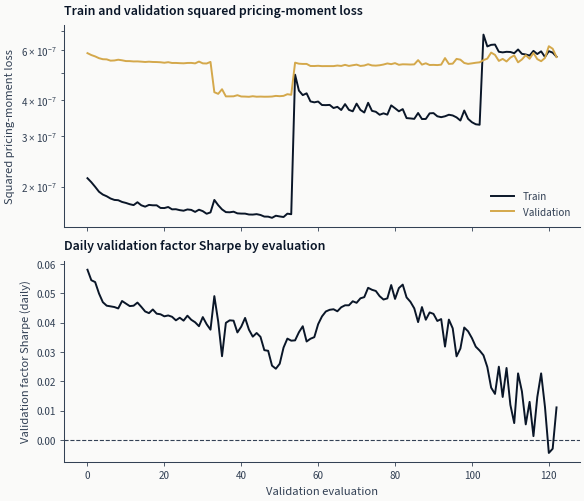

In [25]:
history_frame = pl.DataFrame(history).with_row_index("evaluation")
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], sharex=True, constrained_layout=True)
axes[0].plot(
    history_frame["evaluation"], history_frame["loss_train"], color=COLORS["blue"], label="Train"
)
axes[0].plot(
    history_frame["evaluation"],
    history_frame["loss_valid"],
    color=COLORS["amber"],
    label="Validation",
)
axes[0].set_yscale("log")
axes[0].set_ylabel("Squared pricing-moment loss")
axes[0].legend()
add_message_title(axes[0], "Train and validation squared pricing-moment loss")
axes[1].plot(history_frame["evaluation"], history_frame["sharpe_valid"], color=COLORS["blue"])
zero_line(axes[1])
axes[1].set_xlabel("Validation evaluation")
axes[1].set_ylabel("Validation factor Sharpe (daily)")
add_message_title(axes[1], "Daily validation factor Sharpe by evaluation")
show_with_alt(
    fig,
    "Two stacked panels sharing an x-axis of validation-evaluation index. The upper panel "
    "plots the squared pricing-moment loss on a log axis for train (navy) and validation "
    "(amber). Both curves shift level abruptly at the three points where a new adversarial "
    "instrument round begins; train runs well below validation through the first two "
    "rounds and the two converge in the last. The lower panel plots the daily validation "
    "factor Sharpe against a dashed zero line: it starts near its highest value, dips and "
    "recovers through the middle of training, and falls back towards zero by the right "
    "edge.",
)

## 5. Frozen SDF evaluation

The selected SDF now runs sequentially through train, validation, and test.
This is the first test access. The factor is $1-M$, not $M-1$.

In [26]:
def frozen_factor_paths() -> dict[str, np.ndarray]:
    """Run the frozen SDF sequentially through all three segments."""
    sdf_net.eval()
    state = None
    paths = {}
    with torch.no_grad():
        for name in ("train", "valid", "test"):
            weights, state = sdf_net(data[name].features, data[name].macro, data[name].mask, state)
            factor, _ = construct_sdf(weights, data[name].returns)
            paths[name] = factor.cpu().numpy()
    return paths

In [27]:
factor_paths = frozen_factor_paths()
factor_metrics = {}
for name, values in factor_paths.items():
    daily_sharpe = float(values.mean() / values.std(ddof=1))
    factor_metrics[name] = {"daily": daily_sharpe, "annual": daily_sharpe * np.sqrt(252)}
    print(f"{name}: daily Sharpe={daily_sharpe:.3f}, annualized={daily_sharpe * np.sqrt(252):.2f}")

train: daily Sharpe=0.081, annualized=1.28
valid: daily Sharpe=0.053, annualized=0.84
test: daily Sharpe=-0.000, annualized=-0.01


Test pricing errors summarize $E[M R^e_i]$ for each asset. The figure below
plots the mean signed error inside each decile of the per-asset distribution.
Whether a small subset carries the residual moment violations is a question
about magnitude, so it is answered by the printed concentration share rather
than by the signed deciles.

In [28]:
sdf_net.eval()
state = None
with torch.no_grad():
    for name in ("train", "valid", "test"):
        test_weights, state = sdf_net(data[name].features, data[name].macro, data[name].mask, state)
test_factor, test_sdf = construct_sdf(test_weights, data["test"].returns)
test_counts = data["test"].mask.sum(dim=0).clamp(min=1)
pricing_errors = (
    ((test_sdf[:, None] * data["test"].returns * data["test"].mask).sum(dim=0) / test_counts)
    .cpu()
    .numpy()
)
observed_errors = pricing_errors[data["test"].mask.any(dim=0).cpu().numpy()]
error_groups = np.array_split(np.sort(observed_errors), 10)
decile_means = np.array([group.mean() for group in error_groups])
absolute_errors = np.abs(observed_errors)
top_tenth = int(np.ceil(0.1 * len(absolute_errors)))
concentration = float(np.sort(absolute_errors)[-top_tenth:].sum() / absolute_errors.sum())
print(
    f"Test pricing errors: {len(observed_errors)} assets, decile means "
    f"{10_000 * decile_means[0]:.1f} to {10_000 * decile_means[-1]:.1f} bp; "
    f"the largest tenth by absolute error carries {concentration:.1%} of the total"
)

Test pricing errors: 199 assets, decile means -13.0 to 11.8 bp; the largest tenth by absolute error carries 30.0% of the total


## 6. Beta-network predictive head

The beta target is the contemporaneously aligned product
$R^e_{i,t+1}F_{t+1}$. Scaling by the training factor volatility improves
optimization but does not change asset ranks.

In [29]:
class BetaNetwork(nn.Module):
    """Predict conditional return-factor covariance from current information."""

    def __init__(self, n_features: int, n_macro: int):
        super().__init__()
        self.lstm = nn.LSTM(n_macro, 8, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(n_features + 8, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, features, macro, state=None):
        macro_state, state = self.lstm(macro.unsqueeze(0), state)
        expanded = macro_state.squeeze(0).unsqueeze(1).expand(-1, features.shape[1], -1)
        prediction = self.ffn(torch.cat([features, expanded], dim=-1)).squeeze(-1)
        return prediction, state

Beta checkpoints minimize validation MSE with the LSTM state carried from the
training segment. Test is not read during this second selection step.

In [30]:
def beta_loss(prediction, target, mask) -> torch.Tensor:
    """Masked mean squared error for the beta target."""
    return (prediction[mask] - target[mask]).square().mean()

This validation helper runs only the training and validation segments and
preserves their chronological LSTM state.

In [31]:
def evaluate_beta_train_valid() -> tuple[float, float]:
    """Return beta-target MSE on train and validation without test access."""
    beta_net.eval()
    with torch.no_grad():
        train_prediction, train_state = beta_net(data["train"].features, data["train"].macro)
        valid_prediction, _ = beta_net(data["valid"].features, data["valid"].macro, train_state)
        train_loss = float(beta_loss(train_prediction, beta_targets["train"], data["train"].mask))
        valid_loss = float(beta_loss(valid_prediction, beta_targets["valid"], data["valid"].mask))
    return train_loss, valid_loss

In [32]:
factor_scale = max(float(np.std(factor_paths["train"], ddof=1)), 1e-8)
beta_targets = {
    name: data[name].returns
    * torch.tensor(factor_paths[name] / factor_scale, device=device)[:, None]
    for name in data
}
beta_net = BetaNetwork(len(feature_names), len(macro_names)).to(device)
beta_optimizer = optim.Adam(beta_net.parameters(), lr=LEARNING_RATE)
best_beta_state = deepcopy(beta_net.state_dict())
best_beta_valid = float("inf")
best_beta_epoch = 0
beta_history = []
stale = 0

for epoch in range(BETA_EPOCHS):
    beta_net.train()
    prediction, _ = beta_net(data["train"].features, data["train"].macro)
    loss = beta_loss(prediction, beta_targets["train"], data["train"].mask)
    beta_optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(beta_net.parameters(), 1.0)
    beta_optimizer.step()
    if (epoch + 1) % EVAL_EVERY:
        continue
    train_loss, valid_loss = evaluate_beta_train_valid()
    beta_history.append({"epoch": epoch + 1, "train_mse": train_loss, "valid_mse": valid_loss})
    if valid_loss < best_beta_valid:
        best_beta_valid = valid_loss
        best_beta_state = deepcopy(beta_net.state_dict())
        best_beta_epoch = epoch + 1
        stale = 0
    else:
        stale += 1
    if stale >= BETA_PATIENCE:
        break

beta_net.load_state_dict(best_beta_state)
print(f"Selected beta checkpoint: epoch={best_beta_epoch}, validation MSE={best_beta_valid:.6e}")

Selected beta checkpoint: epoch=400, validation MSE=3.897337e-04


The frozen beta network now reaches test for the first time. Rank IC is
computed separately for each return date and summarized with a HAC interval.

In [33]:
beta_net.eval()
state = None
with torch.no_grad():
    for name in ("train", "valid", "test"):
        beta_prediction, state = beta_net(data[name].features, data[name].macro, state)
test_prediction = beta_prediction.cpu().numpy()
test_returns = data["test"].returns.cpu().numpy()
test_mask = data["test"].mask.cpu().numpy()

rows = []
for date_index, timestamp in enumerate(data["test"].dates):
    for symbol_index in np.flatnonzero(test_mask[date_index]):
        rows.append(
            (
                timestamp,
                symbols[symbol_index],
                float(test_prediction[date_index, symbol_index]),
                float(test_returns[date_index, symbol_index]),
            )
        )
metric_frame = pl.DataFrame(
    rows, schema=["timestamp", "symbol", "prediction", "forward_return"], orient="row"
)

In [34]:
ic_series = cross_sectional_ic_series(
    metric_frame,
    metric_frame,
    pred_col="prediction",
    ret_col="forward_return",
    date_col="timestamp",
    entity_col="symbol",
    min_obs=20,
)
ic_uncertainty = compute_ic_uncertainty(ic_series, horizon=1, n_boot=N_BOOTSTRAP, seed=SEED)
print(
    f"Test beta IC={ic_uncertainty['mean_ic']:.4f} "
    f"[{ic_uncertainty['ci_hac_lower']:.4f}, {ic_uncertainty['ci_hac_upper']:.4f}], "
    f"HAC p={ic_uncertainty['p_hac']:.3f}, dates={ic_series.height}"
)

Test beta IC=-0.0028 [-0.0121, 0.0064], HAC p=0.548, dates=938


## 7. Test diagnostics

Factor Sharpe and pricing errors assess the learned pricing object. Beta rank
IC asks the separate forecasting question. Neither diagnostic substitutes for
the other.

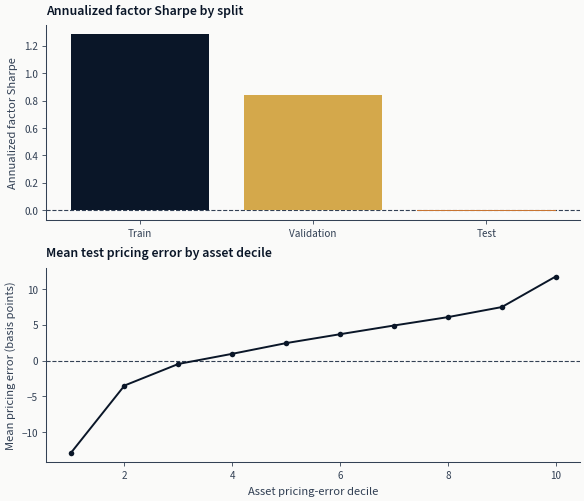

In [35]:
colors = ml4t_palette(3, categorical=True)
beta_history_frame = pl.DataFrame(beta_history)
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"])
names = ["Train", "Validation", "Test"]
annual_sharpes = [factor_metrics[key]["annual"] for key in ("train", "valid", "test")]
axes[0].bar(names, annual_sharpes, color=colors)
zero_line(axes[0])
axes[0].set_ylabel("Annualized factor Sharpe")
add_message_title(axes[0], "Annualized factor Sharpe by split")
axes[1].plot(range(1, 11), 10_000 * decile_means, color=COLORS["blue"], marker="o")
zero_line(axes[1])
axes[1].set_xlabel("Asset pricing-error decile")
axes[1].set_ylabel("Mean pricing error (basis points)")
add_message_title(axes[1], "Mean test pricing error by asset decile")
show_with_alt(
    fig,
    "Two stacked panels. The upper panel is a bar chart of annualized factor Sharpe for "
    "the train, validation and test splits against a dashed zero line; the train and "
    "validation bars stand well above zero and the test bar is too close to zero to see. "
    "The lower panel joins ten markers with a line, plotting the mean pricing error in "
    "basis points inside each decile of the per-asset pricing-error distribution against "
    "a dashed zero line. Because the deciles are ordered by that error, the series rises "
    "from a negative value in the first decile, crosses zero in the low middle deciles, "
    "and reaches its largest positive value in the tenth.",
)

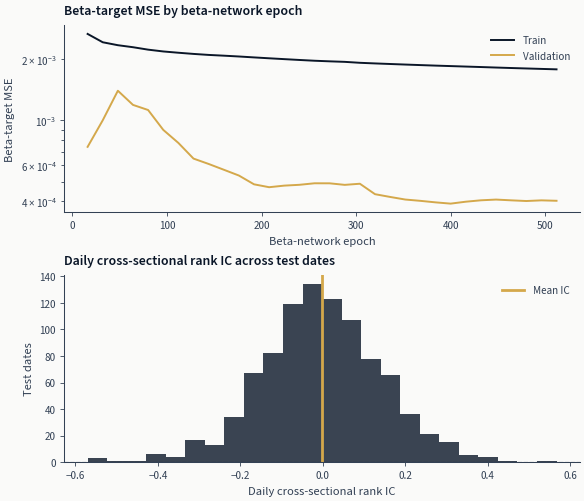

In [36]:
daily_ics = ic_series["ic"].to_numpy()
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"])
axes[0].plot(
    beta_history_frame["epoch"],
    beta_history_frame["train_mse"],
    color=COLORS["blue"],
    label="Train",
)
axes[0].plot(
    beta_history_frame["epoch"],
    beta_history_frame["valid_mse"],
    color=COLORS["amber"],
    label="Validation",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("Beta-network epoch")
axes[0].set_ylabel("Beta-target MSE")
axes[0].legend()
add_message_title(axes[0], "Beta-target MSE by beta-network epoch")
axes[1].hist(daily_ics[np.isfinite(daily_ics)], bins=24, color=COLORS["blue"], alpha=0.8)
zero_line(axes[1])
axes[1].axvline(ic_uncertainty["mean_ic"], color=COLORS["amber"], linewidth=2, label="Mean IC")
axes[1].set_xlabel("Daily cross-sectional rank IC")
axes[1].set_ylabel("Test dates")
axes[1].legend()
add_message_title(axes[1], "Daily cross-sectional rank IC across test dates")
show_with_alt(
    fig,
    "Two stacked panels. The upper panel plots beta-target MSE on a log axis against "
    "beta-network epoch for train (navy) and validation (amber). Train declines smoothly "
    "across the whole range. Validation starts below it, rises to a peak inside the first "
    "hundred epochs, then falls back below train and flattens. The lower panel is a "
    "histogram of the daily cross-sectional rank IC over the test dates: roughly "
    "symmetric, centered near zero, spanning about -0.6 to 0.6, with a vertical amber "
    "line marking the mean.",
)

Validation MSE below train MSE in the upper panel does not mean the network
generalizes better than it fits. The two curves measure the same loss on
different samples of the beta target, the return-factor product, whose scale
is not constant across windows. Only movement along the validation curve
supports the checkpoint comparison.

## 8. Takeaways

1. **Timing defines the SDF.** Current ranked characteristics and delayed
   market state determine weights for the next trading day's excess returns.
2. **The sign matters.** The paper's factor is $F=1-M=\omega^\top R^e$;
   reversing it would reverse the economic interpretation of beta signals.
3. **Selection stops before test.** Validation chooses the SDF and beta
   checkpoints. Test enters only after both networks are frozen.
4. **Pricing and prediction differ.** Factor Sharpe and pricing errors assess
   the kernel; daily rank IC assesses the beta network's asset ordering.
5. **This remains an adaptation.** Daily data, a fixed training-defined liquid
   universe, current-snapshot FRED data, and gross-normalized weights make the
   mechanics inspectable but do not reproduce the paper's monthly experiment.

The next notebook,
[`08_supervised_autoencoder`](08_supervised_autoencoder.ipynb), returns to a
supervised representation whose bottleneck is trained directly for prediction.